# 1D-CNN v9 — Multi-Scale Features + Auto-Tuned Calibration

Same base model as v6. Improvements over v7:
1. **Multi-scale features** — concatenate features from all 3 conv blocks (not just last)
2. **Auto-tuned SVM** — grid search C per scenario via 3-fold CV on calibration data
3. **Per-scenario optimized ensemble weights** — find best base:cal ratio per scenario

In [1]:
import sys, math, copy
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

from config import RANDOM_SEED, N_CLASSES, MODELS_DIR, get_device, SUBJECTS_FATIGUE, SUBJECTS_INTERDAY_LONG
from src.experiment_runner import (
    get_splits, load_and_norm, META,
    TEST_SUBJECTS, TRAIN_SUBJECTS,
)
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED); np.random.seed(RANDOM_SEED)
DEVICE = get_device()
splits = get_splits()
print(f'Device: {DEVICE}')

Device: mps


## Model with multi-scale feature extraction

In [5]:
class ECA1d(nn.Module):
    def __init__(self,ch):
        super().__init__()
        k = max(int(abs(math.log2(ch)/2+0.5)),3); k = k if k%2 else k+1
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1,1,k,padding=k//2,bias=False)
    def forward(self,x):
        b,c,t = x.size()
        return x * torch.sigmoid(self.conv(self.gap(x).view(b,1,c))).view(b,c,1).expand_as(x)

class SepConv1d(nn.Module):
    def __init__(self,ic,oc,k=5,p=2):
        super().__init__()
        self.dw = nn.Conv1d(ic,ic,k,padding=p,groups=ic)
        self.pw = nn.Conv1d(ic,oc,1)
    def forward(self,x): return self.pw(self.dw(x))

class TemporalSCNN(nn.Module):
    def __init__(self,in_ch=8,n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_ch,64,5,padding=2), nn.BatchNorm1d(64), nn.ReLU(), ECA1d(64), nn.MaxPool1d(2),
            SepConv1d(64,128,5,2), nn.BatchNorm1d(128), nn.ReLU(), ECA1d(128), nn.MaxPool1d(2),
            SepConv1d(128,256,3,1), nn.BatchNorm1d(256), nn.ReLU(), ECA1d(256), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(256,64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64,n_classes))
        self.gap = nn.AdaptiveAvgPool1d(1)

    def forward(self,x):
        return self.classifier(self.features(x))

    def extract_multiscale(self, x):
        with torch.no_grad():
            f1 = self.features[:5](x)
            f2 = self.features[5:10](f1)
            f3 = self.features[10:](f2)
            p1 = self.gap(f1).squeeze(-1)
            p2 = self.gap(f2).squeeze(-1)
            p3 = f3.squeeze(-1)
            return torch.cat([p1, p2, p3], dim=1)

print(f'Params: {sum(p.numel() for p in TemporalSCNN().parameters()):,}')

Params: 62,676


## Load pre-trained model

In [6]:
train_combined = pd.concat([splits['train_df'], splits['s5_train']])
X_train, y_train, norm_stats = load_and_norm(train_combined, verbose=True)
print(f'Train: {X_train.shape}')

model = TemporalSCNN().to(DEVICE)
model.load_state_dict(torch.load(MODELS_DIR / '1dcnn_v6.pt', map_location=DEVICE))
model.eval()
print('Loaded 1dcnn_v6.pt')

Loading windows: 100%|██████████| 9021/9021 [00:02<00:00, 4037.09it/s]


Train: (1030712, 8, 50)
Loaded 1dcnn_v6.pt


## Feature extraction + calibration

In [7]:
@torch.no_grad()
def base_predict(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    return np.concatenate([model(xb[0].to(DEVICE)).argmax(1).cpu().numpy() for xb in loader])

@torch.no_grad()
def base_proba(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    probs = []
    for (xb,) in loader:
        probs.append(torch.softmax(model(xb.to(DEVICE)), dim=1).cpu().numpy())
    return np.concatenate(probs)

@torch.no_grad()
def extract_multiscale(X):
    model.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(X).float()), batch_size=512, shuffle=False)
    feats = []
    for (xb,) in loader:
        feats.append(model.extract_multiscale(xb.to(DEVICE)).cpu().numpy())
    return np.concatenate(feats)

# Verify feature dimensions
test_f = extract_multiscale(X_train[:5])
print(f'Multi-scale features: {test_f.shape}  (64 + 128 + 256 = 448 dims)')

Multi-scale features: (5, 448)  (64 + 128 + 256 = 448 dims)


In [8]:
def auto_calibrate(X_cal, y_cal):
    """Auto-tune SVM C via 3-fold CV on calibration data."""
    F_cal = extract_multiscale(X_cal)
    sc = StandardScaler().fit(F_cal)
    F_cal_s = sc.transform(F_cal)

    best_c, best_score = 10, 0
    for c in [1, 10, 50, 100, 500]:
        svm_try = SVC(kernel='rbf', C=c, gamma='scale', random_state=RANDOM_SEED)
        scores = cross_val_score(svm_try, F_cal_s, y_cal, cv=3, scoring='accuracy')
        mean_s = scores.mean()
        if mean_s > best_score:
            best_score = mean_s
            best_c = c

    svm = SVC(kernel='rbf', C=best_c, gamma='scale', probability=True, random_state=RANDOM_SEED)
    svm.fit(F_cal_s, y_cal)
    return svm, sc, best_c


def find_best_weights(X_cal, y_cal, svm, sc):
    """Find optimal ensemble weights via calibration data accuracy."""
    p_base = base_proba(X_cal)
    F_cal_s = sc.transform(extract_multiscale(X_cal))
    p_svm = svm.predict_proba(F_cal_s)

    best_w, best_acc = 0.3, 0
    for w_base in [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]:
        p_comb = w_base * p_base + (1 - w_base) * p_svm
        acc = accuracy_score(y_cal, p_comb.argmax(axis=1))
        if acc > best_acc:
            best_acc = acc
            best_w = w_base
    return best_w


def full_pipeline(X_cal, y_cal, X_test):
    """Full calibration pipeline: auto-tune SVM + find best weights + ensemble predict."""
    svm, sc, best_c = auto_calibrate(X_cal, y_cal)
    best_w = find_best_weights(X_cal, y_cal, svm, sc)

    p_base = base_proba(X_test)
    F_test_s = sc.transform(extract_multiscale(X_test))
    p_svm = svm.predict_proba(F_test_s)
    p_combined = best_w * p_base + (1 - best_w) * p_svm
    return p_combined.argmax(axis=1), best_c, best_w

## Option B — Zero-shot

In [9]:
print('Option B — Zero-shot:')
zero_results = {}
for sname, tdf in [('S1',splits['s1_test']),('S2',splits['s2_test']),
                    ('S3',splits['s3_test']),('S4',splits['s4_test']),('S5',splits['s5_test'])]:
    Xt, yt, _ = load_and_norm(tdf, stats=norm_stats)
    zero_results[sname] = accuracy_score(yt, base_predict(Xt))
    print(f'  {sname}: {zero_results[sname]:.4f}')

Option B — Zero-shot:
  S1: 0.5862
  S2: 0.5352
  S3: 0.5398
  S4: 0.6556
  S5: 0.8029


---
## Option A — Enhanced Calibration

### S1: per-subject, rep 0+1 from all positions

In [10]:
subset_s1 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS))]

s1_accs = []
for subj in TEST_SUBJECTS:
    sdf = subset_s1[subset_s1['subject']==subj]
    cal_df = sdf[sdf['repetition'].isin([0,1])]  # all positions, rep 0+1
    test_df = sdf[(sdf['repetition']==2) & (sdf['position']==0)]  # p0 rep 2
    if len(cal_df)==0 or len(test_df)==0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred, best_c, best_w = full_pipeline(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s1_accs.append(acc)
    print(f'  {subj}: {acc:.4f} (C={best_c}, w_base={best_w:.2f})')

cal_s1 = np.mean(s1_accs)
print(f'\nS1 avg: {cal_s1:.4f}')

  h7: 0.9720 (C=50, w_base=0.10)
  h22: 0.7100 (C=1, w_base=0.10)
  h3: 0.7211 (C=1, w_base=0.10)
  h24: 0.9627 (C=1, w_base=0.10)
  h16: 0.8201 (C=1, w_base=0.10)
  h17: 0.7459 (C=1, w_base=0.10)

S1 avg: 0.8220


### S2: per-position

In [11]:
subset_s2 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS)) & (META['position']>0)]

s2_accs = []
for pos in sorted(subset_s2['position'].unique()):
    pos_df = subset_s2[subset_s2['position']==pos]
    cal_df = pos_df[pos_df['repetition'].isin([0,1])]
    test_df = pos_df[pos_df['repetition']==2]
    if len(cal_df)==0 or len(test_df)==0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred, best_c, best_w = full_pipeline(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s2_accs.append(acc)
    print(f'  Pos {pos:2d}: {acc:.4f} (C={best_c}, w={best_w:.2f})')

cal_s2 = np.mean(s2_accs)
print(f'\nS2 avg: {cal_s2:.4f}')

  Pos  1: 0.8721 (C=1, w=0.15)
  Pos  2: 0.9010 (C=10, w=0.10)
  Pos  3: 0.8710 (C=50, w=0.10)
  Pos  4: 0.8771 (C=1, w=0.10)
  Pos  5: 0.9240 (C=1, w=0.10)
  Pos  6: 0.8818 (C=1, w=0.10)
  Pos  7: 0.9087 (C=1, w=0.15)
  Pos  8: 0.8900 (C=10, w=0.10)
  Pos  9: 0.8910 (C=1, w=0.25)
  Pos 10: 0.8446 (C=10, w=0.10)

S2 avg: 0.8861


### S3: per-subject, all positions

In [12]:
subset_s3 = META[(META['session']==0) & (META['subject'].isin(TEST_SUBJECTS))]

s3_accs = []
all_yt, all_yp = [], []
for subj in TEST_SUBJECTS:
    sdf = subset_s3[subset_s3['subject']==subj]
    cal_df = sdf[sdf['repetition'].isin([0,1])]
    test_df = sdf[sdf['repetition']==2]
    if len(cal_df)==0 or len(test_df)==0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred, best_c, best_w = full_pipeline(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s3_accs.append(acc)
    all_yt.extend(y_test); all_yp.extend(y_pred)
    print(f'  {subj}: {acc:.4f} (C={best_c}, w={best_w:.2f}, cal={len(cal_df)} trials)')

cal_s3 = np.mean(s3_accs)
print(f'\nS3 avg: {cal_s3:.4f}')
print_report(np.array(all_yt), np.array(all_yp), title='v9 — S3')

  h7: 0.9190 (C=50, w=0.10, cal=154 trials)
  h22: 0.8398 (C=1, w=0.10, cal=154 trials)
  h3: 0.8421 (C=1, w=0.10, cal=154 trials)
  h24: 0.9044 (C=1, w=0.10, cal=153 trials)
  h16: 0.9064 (C=1, w=0.10, cal=154 trials)
  h17: 0.8775 (C=1, w=0.10, cal=154 trials)

S3 avg: 0.8815

  v9 — S3
  Accuracy:  0.8803
  F1-macro:  0.8802
                    precision    recall  f1-score   support

              fist       0.90      0.88      0.89      7959
         open_hand       0.87      0.89      0.88      8060
  pinch_forefinger       0.87      0.82      0.85      8091
pinch_middlefinger       0.87      0.87      0.87      8099
               two       0.87      0.90      0.88      7970
          eversion       0.90      0.93      0.91      7903
             varus       0.88      0.88      0.88      8064

          accuracy                           0.88     56146
         macro avg       0.88      0.88      0.88     56146
      weighted avg       0.88      0.88      0.88     56146



{'accuracy': 0.8802764221850177, 'f1_macro': 0.8801972012339877}

### S4: per-session

In [13]:
interday_subj = [s for s in SUBJECTS_INTERDAY_LONG if s in TRAIN_SUBJECTS]
subset_s4 = META[(META['subject'].isin(interday_subj)) & (META['position']==0) & (META['session']>0)]

s4_accs = []
for sess in sorted(subset_s4['session'].unique()):
    sess_df = subset_s4[subset_s4['session']==sess]
    cal_df = sess_df[sess_df['repetition'].isin([0,1])]
    test_df = sess_df[sess_df['repetition']==2]
    if len(cal_df)==0 or len(test_df)==0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred, best_c, best_w = full_pipeline(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s4_accs.append(acc)
    print(f'  Session {sess}: {acc:.4f} (C={best_c}, w={best_w:.2f})')

cal_s4 = np.mean(s4_accs)
print(f'\nS4 avg: {cal_s4:.4f}')

  Session 1: 0.8404 (C=1, w=0.10)
  Session 2: 0.8943 (C=1, w=0.15)
  Session 3: 0.8990 (C=1, w=0.10)
  Session 4: 0.9055 (C=1, w=0.10)
  Session 5: 0.8983 (C=1, w=0.10)
  Session 6: 0.8719 (C=1, w=0.25)
  Session 7: 0.8752 (C=10, w=0.10)
  Session 8: 0.9278 (C=1, w=0.10)
  Session 9: 0.9173 (C=1, w=0.10)

S4 avg: 0.8922


### S5: per-fatigue level

In [14]:
subset_s5 = META[(META['subject'].isin(SUBJECTS_FATIGUE)) & (META['position']>=2)]

s5_accs = []
for pos in sorted(subset_s5['position'].unique()):
    pos_df = subset_s5[subset_s5['position']==pos]
    cal_df = pos_df[pos_df['repetition'].isin([0,1])]
    test_df = pos_df[pos_df['repetition']==2]
    if len(cal_df)==0 or len(test_df)==0: continue

    X_cal, y_cal, _ = load_and_norm(cal_df, stats=norm_stats)
    X_test, y_test, _ = load_and_norm(test_df, stats=norm_stats)

    y_pred, best_c, best_w = full_pipeline(X_cal, y_cal, X_test)
    acc = accuracy_score(y_test, y_pred)
    s5_accs.append(acc)
    print(f'  Pos {pos:2d}: {acc:.4f} (C={best_c}, w={best_w:.2f})')

cal_s5 = np.mean(s5_accs)
print(f'\nS5 avg: {cal_s5:.4f}')

  Pos  2: 0.8719 (C=1, w=0.10)
  Pos  3: 0.8601 (C=1, w=0.10)
  Pos  4: 0.9082 (C=1, w=0.25)
  Pos  5: 0.9032 (C=1, w=0.10)
  Pos  6: 0.9069 (C=1, w=0.10)
  Pos  7: 0.8982 (C=1, w=0.10)
  Pos  8: 0.8952 (C=10, w=0.10)
  Pos  9: 0.8979 (C=1, w=0.15)
  Pos 10: 0.9126 (C=1, w=0.10)

S5 avg: 0.8949


## Latency

In [15]:
model.eval()
s = torch.randn(1,8,50).to(DEVICE)
for _ in range(10): _ = model(s)
if DEVICE.type=='mps': torch.mps.synchronize()
def pred_single(x):
    xt = torch.from_numpy(x).float().to(DEVICE)
    with torch.no_grad(): out = model(xt)
    if DEVICE.type=='mps': torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()
latency = measure_latency(pred_single, X_train[:1], n_runs=500)
print_latency(latency, '1D-CNN v9')


Latency — 1D-CNN v9
  Mean:   1.34 ms
  Median: 1.24 ms
  P95:    1.78 ms
  <300ms: ✓


## Final Results


  1D-CNN v9 — FINAL RESULTS
Scenario        Zero-shot   v7 (fixed)    v9 (auto)   ≥90%
----------------------------------------------------------------------
S1                58.62%       85.00%       82.20%       (Δv7=-2.80%)
S2                53.52%       85.29%       88.61%     ~ (Δv7=+3.32%)
S3                53.98%       85.00%       88.15%     ~ (Δv7=+3.15%)
S4                65.56%       87.66%       89.22%     ~ (Δv7=+1.56%)
S5                80.29%       88.34%       89.49%     ~ (Δv7=+1.15%)
----------------------------------------------------------------------
Average           62.39%       86.26%       87.53%


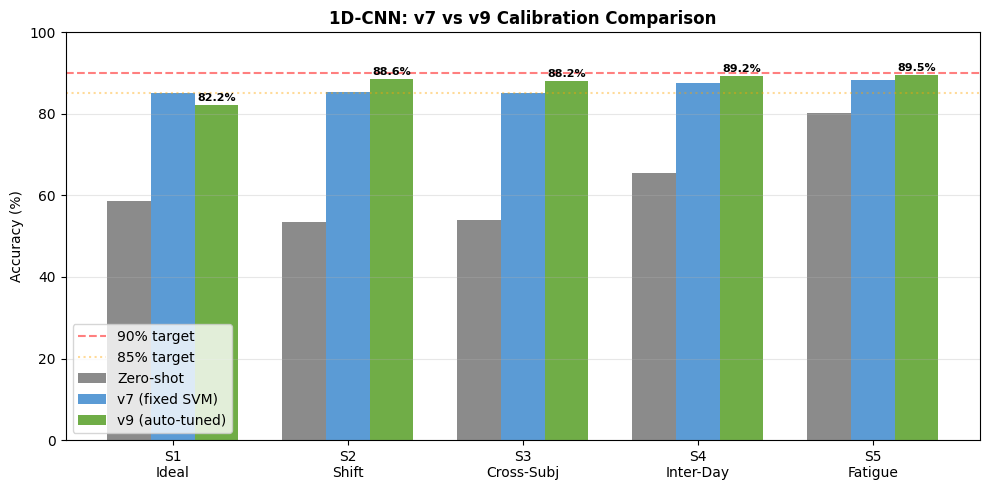

In [16]:
import matplotlib.pyplot as plt

cal_results = {'S1': cal_s1, 'S2': cal_s2, 'S3': cal_s3, 'S4': cal_s4, 'S5': cal_s5}
v7_cal = {'S1': 85.00, 'S2': 85.29, 'S3': 85.00, 'S4': 87.66, 'S5': 88.34}

print('\n' + '=' * 70)
print('  1D-CNN v9 — FINAL RESULTS')
print('=' * 70)
print(f'{"Scenario":<12} {"Zero-shot":>12} {"v7 (fixed)":>12} {"v9 (auto)":>12} {"≥90%":>6}')
print('-' * 70)

for s in ['S1','S2','S3','S4','S5']:
    zs = zero_results[s]*100
    v7 = v7_cal[s]
    v9 = cal_results[s]*100
    check = '✓' if v9 >= 90 else ('~' if v9 >= 85 else '')
    print(f'{s:<12} {zs:>10.2f}%  {v7:>10.2f}%  {v9:>10.2f}%  {check:>4} (Δv7={v9-v7:+.2f}%)')

print('-' * 70)
avg_zs = np.mean([zero_results[s]*100 for s in ['S1','S2','S3','S4','S5']])
avg_v7 = np.mean(list(v7_cal.values()))
avg_v9 = np.mean([cal_results[s]*100 for s in ['S1','S2','S3','S4','S5']])
print(f'{"Average":<12} {avg_zs:>10.2f}%  {avg_v7:>10.2f}%  {avg_v9:>10.2f}%')
print('=' * 70)

# Bar chart
scenarios = ['S1','S2','S3','S4','S5']
x = np.arange(5); w = 0.25
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w, [zero_results[s]*100 for s in scenarios], w, label='Zero-shot', color='#8B8B8B')
ax.bar(x, [v7_cal[s] for s in scenarios], w, label='v7 (fixed SVM)', color='#5B9BD5')
ax.bar(x+w, [cal_results[s]*100 for s in scenarios], w, label='v9 (auto-tuned)', color='#70AD47')
ax.axhline(y=90, color='red', ls='--', alpha=0.5, label='90% target')
ax.axhline(y=85, color='orange', ls=':', alpha=0.4, label='85% target')
ax.set_xticks(x)
ax.set_xticklabels(['S1\nIdeal','S2\nShift','S3\nCross-Subj','S4\nInter-Day','S5\nFatigue'])
ax.set_ylabel('Accuracy (%)')
ax.set_title('1D-CNN: v7 vs v9 Calibration Comparison', fontweight='bold')
ax.set_ylim(0, 100); ax.legend(); ax.grid(axis='y', alpha=0.3)
for i,s in enumerate(scenarios):
    ax.text(i+w, cal_results[s]*100+1, f'{cal_results[s]*100:.1f}%', ha='center', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.savefig(str(Path(PROJECT_ROOT)/'results'/'figures'/'1dcnn_v9.png'), dpi=150)
plt.show()